In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets tensorboard

In [ ]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch Version: 2.10.0+cpu
CUDA Available: False


**Pytorch First Example describing the torch tensors**


In [ ]:
import torch
import torch.nn as nn

# -------------------------------------------------
# DEVICE MANAGEMENT
# -------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------------------
# IMAGE TENSOR (CNN WORLD)
# -------------------------------------------------
# Shape format:
# [batch, channels, height, width]
# -------------------------------------------------
image_batch = torch.randn(4, 3, 64, 64)

print("\nIMAGE TENSOR")
print("Shape:", image_batch.shape)
print("Dtype:", image_batch.dtype)
print("Device:", image_batch.device)

image_batch = image_batch.to(device)

# -------------------------------------------------
# SIMPLE CNN LAYER
# -------------------------------------------------

conv = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    padding=1
).to(device)

cnn_output = conv(image_batch)

print("\nCNN OUTPUT")
print("Shape:", cnn_output.shape)

# -------------------------------------------------
# TEXT TENSOR (TRANSFORMER WORLD)
# -------------------------------------------------
# Shape format:
# [batch, sequence_length]
# -------------------------------------------------

vocab_size = 1000

text_batch = torch.randint(
    low=0,
    high=vocab_size,
    size=(4, 12)
)

print("\nTEXT TENSOR")
print("Shape:", text_batch.shape)
print("Dtype:", text_batch.dtype)
print("Device:", text_batch.device)

text_batch = text_batch.to(device)

# -------------------------------------------------
# EMBEDDING LAYER
# -------------------------------------------------
# Embeddings convert token ids -> vectors
# -------------------------------------------------

embedding = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=32
).to(device)

embedded_text = embedding(text_batch)

print("\nEMBEDDED TEXT")
print("Shape:", embedded_text.shape)

# -------------------------------------------------
# UNIVERSAL PATTERN
# -------------------------------------------------

print("\nUNIVERSAL OBSERVATION")
print("CNN input is a tensor")
print("Transformer input is also a tensor")
print("PyTorch uses one abstraction for every modality")

Using device: cpu

IMAGE TENSOR
Shape: torch.Size([4, 3, 64, 64])
Dtype: torch.float32
Device: cpu

CNN OUTPUT
Shape: torch.Size([4, 8, 64, 64])

TEXT TENSOR
Shape: torch.Size([4, 12])
Dtype: torch.int64
Device: cpu

EMBEDDED TEXT
Shape: torch.Size([4, 12, 32])

UNIVERSAL OBSERVATION
CNN input is a tensor
Transformer input is also a tensor
PyTorch uses one abstraction for every modality


In [ ]:
import torch

x = torch.arange(1,11)
x_stacked = torch.stack([x,x,x,x])

print(x_stacked)

tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])


In [ ]:
vx_stacked = torch.stack([x,x,x,x],dim=1)

print(vx_stacked)

tensor([[ 1,  1,  1,  1],
        [ 2,  2,  2,  2],
        [ 3,  3,  3,  3],
        [ 4,  4,  4,  4],
        [ 5,  5,  5,  5],
        [ 6,  6,  6,  6],
        [ 7,  7,  7,  7],
        [ 8,  8,  8,  8],
        [ 9,  9,  9,  9],
        [10, 10, 10, 10]])


## Pytorch Workflow




In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

## Data (preprocessing and loading)

In [ ]:
weight  = 0.7
bias = 0.3

#create
start,end,step = 0,1,0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

##Splitting data into training and testing set


In [ ]:
train_split = int(0.8 * len(X))
X_train , y_train = X[:train_split],y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]

print(X_train, y_train)

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260],
        [0.4400],
        [0.4540],
        [0.4680],
        [0.4820],
        [0.4960],
        [

In [ ]:
def plot_predictions(train_data = X_train, train_labels = y_train, test_data = X_test, test_labels = y_test, predictions = None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c="b",s=10,label="Training Data")
  plt.scatter(test_data,test_labels,c="r",s=10,label="Testing Data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

  plt.legend(prop={"size":14})

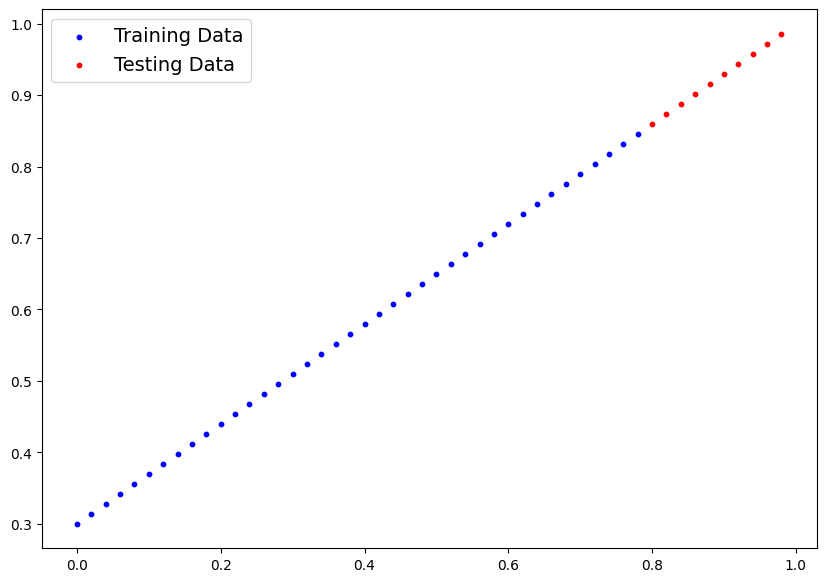

In [ ]:
plot_predictions()

##Linear Regression


In [ ]:
import torch
from torch import nn

class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [ ]:
torch.manual_seed(42)

model_0 = LinearRegression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

In [ ]:
print(y_preds)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [ ]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

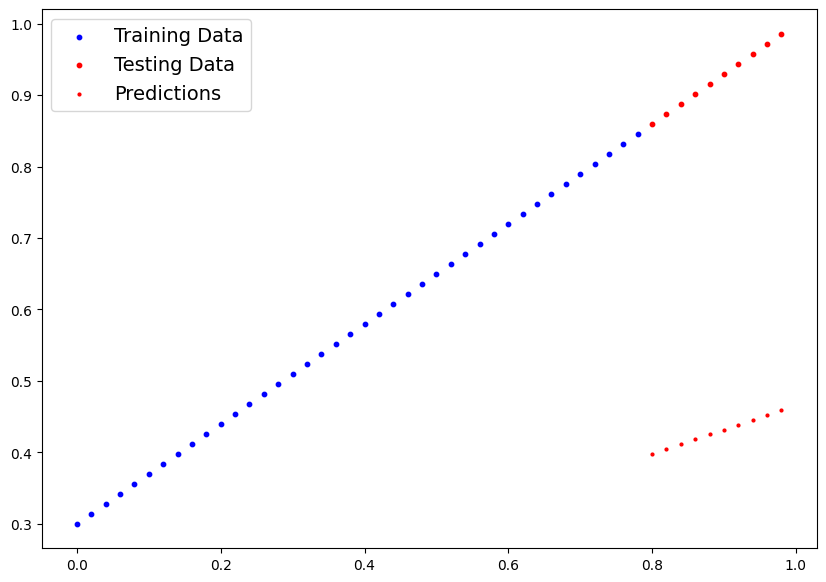

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
loss_function = nn.L1Loss()

with torch.inference_mode():
  y_preds = model_0(X_test)
  l = loss_function(y_preds,y_test)

print(l)



tensor(0.4945)


In [ ]:
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [ ]:
epochs = 1000

for epoch in range(epochs):
  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_function(y_pred,y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()

In [ ]:
model_0.state_dict()


OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
with torch.inference_mode():
  y_preds = model_0(X_test)
  l = loss_function(y_preds,y_test)

print(l)



tensor(0.0084)


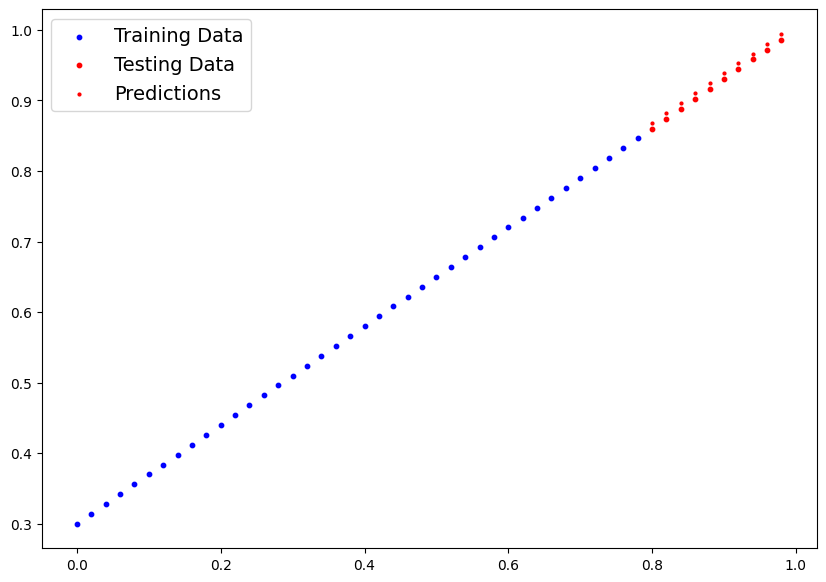

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
torch.save(model_0.state_dict(), 'model_0.pth')
print("Model saved successfully to model_0.pth")

Model saved successfully to model_0.pth


##Pytorch example 2


In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples,
                   noise=0.03,random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(X[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [ ]:
print(y[:5])

[1 1 1 1 0]


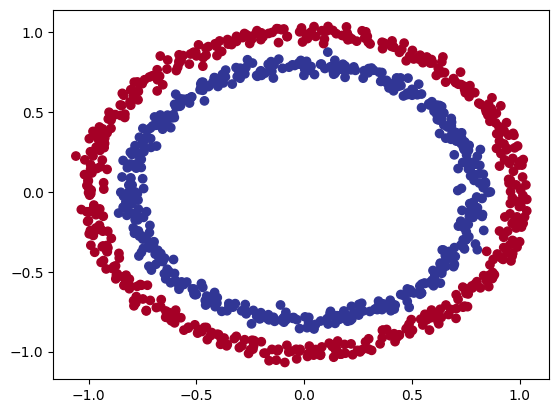

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [ ]:
X.shape,y.shape

((1000, 2), (1000,))

In [ ]:
import torch

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X,y

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         ...,
         [-0.1369, -0.8100],
         [ 0.6704, -0.7675],
         [ 0.2811,  0.9638]]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
         1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
         0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0.,
         1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
         0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
         0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1.,
         1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
         1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [ ]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10) # Takes 2 input features, produces 10 hidden features
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # Takes 10 hidden features, produces 10 hidden features
        self.layer_3 = nn.Linear(in_features=10, out_features=1)  # Takes 10 hidden features, produces 1 output feature (for binary classification)
        self.relu = nn.ReLU() # Non-linear activation function

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pass data through the layers and activation functions
        # This is a common pattern: linear -> non-linear -> linear -> non-linear ...
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_0=CircleModelV0().to(device)



In [ ]:
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples, noise=0.03,random_state=42)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

In [ ]:
# Move data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Train the model
epochs = 1000

for epoch in range(epochs):
    ### Training
    model_0.train() # set model to train mode

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra dimensions
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

    # 2. Calculate loss
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss expects raw logits as input
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval() # set model to eval mode
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate loss
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6963, Acc: 50.00% | Test Loss: 0.6957, Test Acc: 50.00%
Epoch: 10 | Loss: 0.6950, Acc: 50.00% | Test Loss: 0.6944, Test Acc: 50.00%
Epoch: 20 | Loss: 0.6941, Acc: 50.00% | Test Loss: 0.6937, Test Acc: 50.00%
Epoch: 30 | Loss: 0.6936, Acc: 50.00% | Test Loss: 0.6933, Test Acc: 50.00%
Epoch: 40 | Loss: 0.6932, Acc: 49.88% | Test Loss: 0.6929, Test Acc: 49.00%
Epoch: 50 | Loss: 0.6928, Acc: 46.25% | Test Loss: 0.6926, Test Acc: 46.50%
Epoch: 60 | Loss: 0.6926, Acc: 39.12% | Test Loss: 0.6924, Test Acc: 43.50%
Epoch: 70 | Loss: 0.6924, Acc: 47.12% | Test Loss: 0.6922, Test Acc: 50.50%
Epoch: 80 | Loss: 0.6922, Acc: 52.50% | Test Loss: 0.6920, Test Acc: 53.50%
Epoch: 90 | Loss: 0.6921, Acc: 55.00% | Test Loss: 0.6918, Test Acc: 56.00%
Epoch: 100 | Loss: 0.6919, Acc: 52.50% | Test Loss: 0.6916, Test Acc: 53.00%
Epoch: 110 | Loss: 0.6918, Acc: 52.62% | Test Loss: 0.6914, Test Acc: 54.50%
Epoch: 120 | Loss: 0.6916, Acc: 52.00% | Test Loss: 0.6912, Test Acc: 54.50%
Epoch: 130

##Trying Regression

In [13]:
import torch

weight = 0.7
bias = 0.3
start,end,step = 0,1,0.01

X_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias


In [14]:
train_split = int(0.8*len(X_regression))
X_train_regression,y_train_regression = X_regression[:train_split],y_regression[:train_split]
X_test_regression,y_test_regression = X_regression[train_split:],y_regression[train_split:]

In [15]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


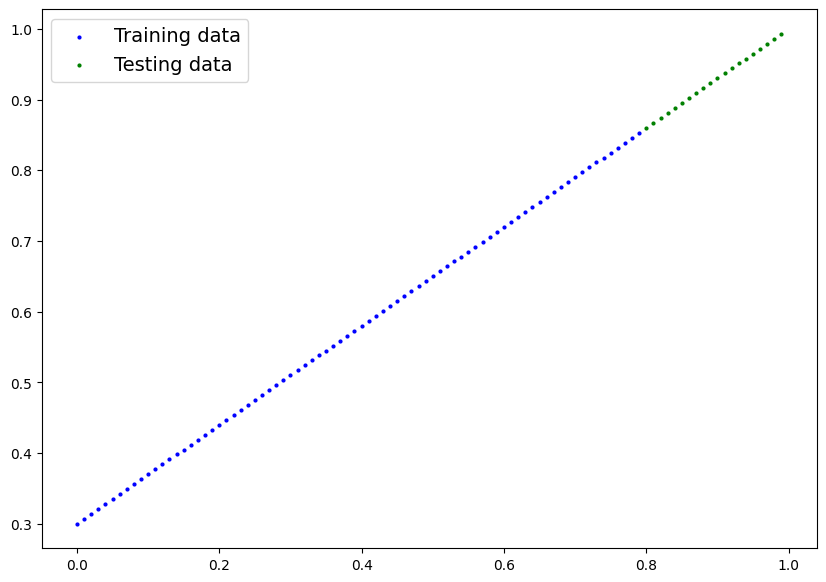

In [16]:
plot_predictions(train_data=X_train_regression,train_labels=y_train_regression,test_data=X_test_regression,test_labels=y_test_regression)

In [17]:
from torch import nn

model_2 = nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
)

model_2,model_2.state_dict()

(Sequential(
   (0): Linear(in_features=1, out_features=10, bias=True)
   (1): Linear(in_features=10, out_features=10, bias=True)
   (2): Linear(in_features=10, out_features=1, bias=True)
 ),
 OrderedDict([('0.weight',
               tensor([[ 0.7645],
                       [ 0.8300],
                       [-0.2343],
                       [ 0.9186],
                       [-0.2191],
                       [ 0.2018],
                       [-0.4869],
                       [ 0.5873],
                       [ 0.8815],
                       [-0.7336]])),
              ('0.bias',
               tensor([ 0.8692,  0.1872,  0.7388,  0.1354,  0.4822, -0.1412,  0.7709,  0.1478,
                       -0.4668,  0.2549])),
              ('1.weight',
               tensor([[-0.1457, -0.0371, -0.1284,  0.2098, -0.2496, -0.1458, -0.0893, -0.1901,
                         0.0298, -0.3123],
                       [ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
            

In [19]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [20]:
torch.manual_seed(42)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_2.to(device)

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [22]:
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression,y_train_regression = X_train_regression.to(device),y_train_regression.to(device)
X_test_regression,y_test_regression = X_test_regression.to(device),y_test_regression.to(device)

In [23]:
for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred,y_train_regression)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_2.eval()

  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred,y_test_regression)

  if epoch%50 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Loss: 0.7599 | Test Loss: 0.5414
Epoch: 50 | Loss: 0.0763 | Test Loss: 0.0210
Epoch: 100 | Loss: 0.0931 | Test Loss: 0.0290
Epoch: 150 | Loss: 0.0714 | Test Loss: 0.0206
Epoch: 200 | Loss: 0.0738 | Test Loss: 0.0285
Epoch: 250 | Loss: 0.0636 | Test Loss: 0.0247
Epoch: 300 | Loss: 0.0675 | Test Loss: 0.0062
Epoch: 350 | Loss: 0.0615 | Test Loss: 0.0119
Epoch: 400 | Loss: 0.0611 | Test Loss: 0.0200
Epoch: 450 | Loss: 0.0504 | Test Loss: 0.0052
Epoch: 500 | Loss: 0.0570 | Test Loss: 0.0106
Epoch: 550 | Loss: 0.0633 | Test Loss: 0.0264
Epoch: 600 | Loss: 0.0486 | Test Loss: 0.0133
Epoch: 650 | Loss: 0.0550 | Test Loss: 0.0069
Epoch: 700 | Loss: 0.0611 | Test Loss: 0.0213
Epoch: 750 | Loss: 0.0613 | Test Loss: 0.0135
Epoch: 800 | Loss: 0.0560 | Test Loss: 0.0143
Epoch: 850 | Loss: 0.0554 | Test Loss: 0.0105
Epoch: 900 | Loss: 0.0557 | Test Loss: 0.0060
Epoch: 950 | Loss: 0.0644 | Test Loss: 0.0255


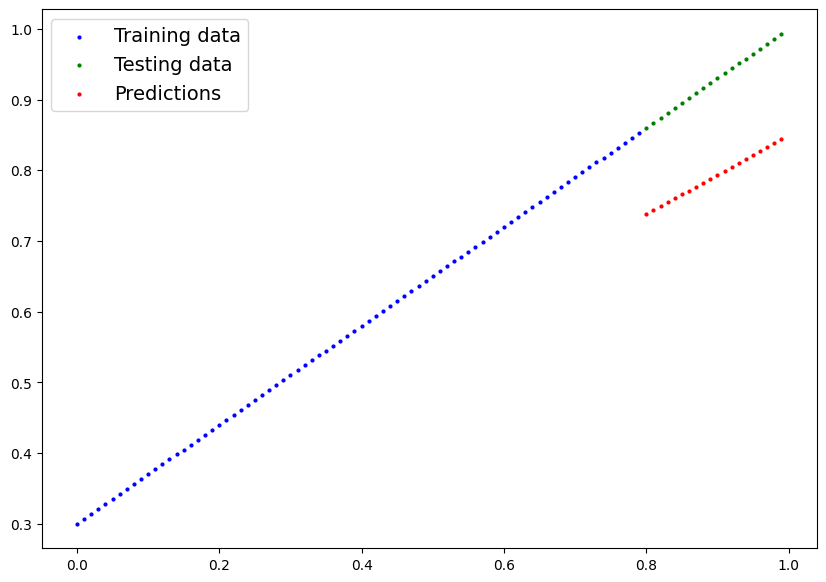

In [24]:
model_2.eval()

with torch.inference_mode():
  y_pred = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression,train_labels=y_train_regression,test_data=X_test_regression,test_labels=y_test_regression,predictions=y_pred)

## Multiclass Classification Example: Blobs Dataset

In [33]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import torch
import matplotlib.pyplot as plt

# 0. Create multiclass data
n_samples = 1000
n_features = 2
n_classes = 4

X_blob, y_blob = make_blobs(n_samples=n_samples,
                            n_features=n_features,
                            centers=n_classes,
                            cluster_std=1.5,
                            random_state=42)

# Convert data to PyTorch tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor) # For multiclass, y should be LongTensor

# Split data into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=42)

print(f"X_blob_train shape: {X_blob_train.shape}")
print(f"y_blob_train shape: {y_blob_train.shape}")
print(f"X_blob_test shape: {X_blob_test.shape}")
print(f"y_blob_test shape: {y_blob_test.shape}")

X_blob_train shape: torch.Size([800, 2])
y_blob_train shape: torch.Size([800])
X_blob_test shape: torch.Size([200, 2])
y_blob_test shape: torch.Size([200])


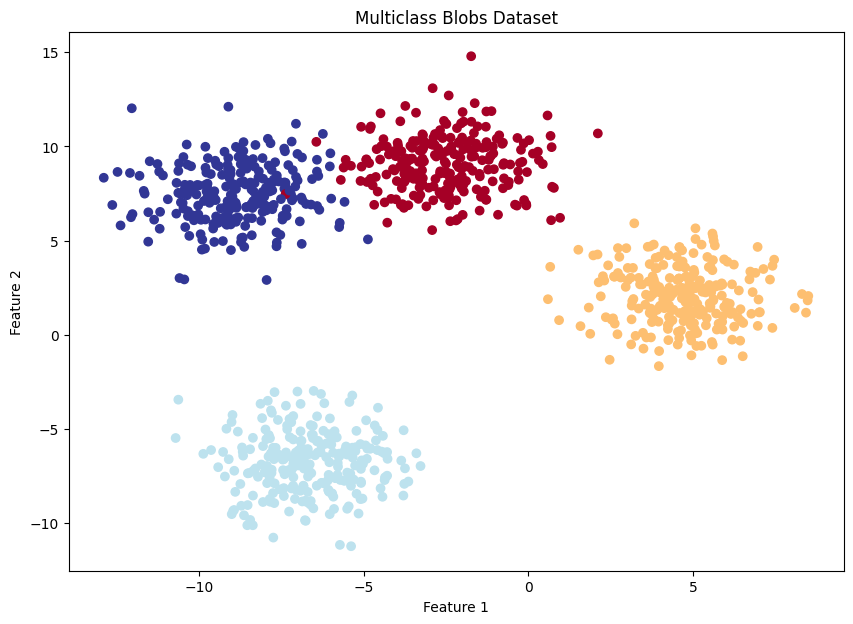

In [34]:
# Visualize the data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)
plt.title("Multiclass Blobs Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Build a Multiclass Classification Model

In [35]:
class BlobModelV0(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

# Instantiate the model
model_1 = BlobModelV0(input_features=n_features,
                      output_features=n_classes,
                      hidden_units=8).to(device)
model_1

BlobModelV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

## Train the Multiclass Classification Model

In [39]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 # Multiply by 100 to get percentage
    return acc

In [40]:
# Create a loss function and optimizer for multiclass classification
loss_fn = nn.CrossEntropyLoss() # For multiclass classification
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

# Move data to the target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Training loop
epochs = 1000

for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_logits = model_1(X_blob_train) # Raw logits
    y_pred_probs = torch.softmax(y_logits, dim=1) # Convert logits to prediction probabilities
    y_pred = torch.argmax(y_pred_probs, dim=1) # Convert prediction probabilities to prediction labels

    # 2. Calculate loss
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train.cpu(), y_pred=y_pred.cpu()) # Ensure tensors are on CPU for accuracy_fn

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_blob_test)
        test_pred_probs = torch.softmax(test_logits, dim=1)
        test_pred = torch.argmax(test_pred_probs, dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test.cpu(), y_pred=test_pred.cpu())

    # Print out what's happening every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.1950, Acc: 70.62% | Test Loss: 1.0250, Test Acc: 78.00%
Epoch: 100 | Loss: 0.0471, Acc: 98.88% | Test Loss: 0.0376, Test Acc: 99.00%
Epoch: 200 | Loss: 0.0315, Acc: 98.88% | Test Loss: 0.0226, Test Acc: 99.50%
Epoch: 300 | Loss: 0.0292, Acc: 98.88% | Test Loss: 0.0193, Test Acc: 99.50%
Epoch: 400 | Loss: 0.0282, Acc: 99.00% | Test Loss: 0.0176, Test Acc: 99.50%
Epoch: 500 | Loss: 0.0276, Acc: 99.00% | Test Loss: 0.0166, Test Acc: 99.50%
Epoch: 600 | Loss: 0.0271, Acc: 99.00% | Test Loss: 0.0158, Test Acc: 99.50%
Epoch: 700 | Loss: 0.0267, Acc: 99.00% | Test Loss: 0.0153, Test Acc: 99.50%
Epoch: 800 | Loss: 0.0264, Acc: 99.00% | Test Loss: 0.0148, Test Acc: 99.50%
Epoch: 900 | Loss: 0.0260, Acc: 99.25% | Test Loss: 0.0144, Test Acc: 99.50%


## Visualize the Decision Boundary

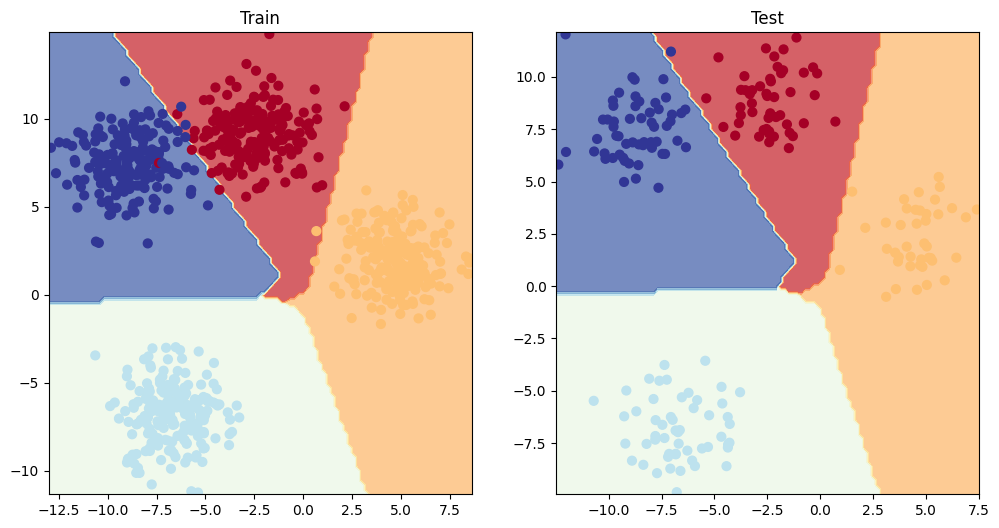

In [41]:
# Plot the decision boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_blob_test, y_blob_test)
plt.show()